In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
from pylab import rcParams
import matplotlib.pyplot as plt
import warnings
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import seaborn as sns

In [2]:
X, y = make_circles(n_samples=100,noise=0.1,random_state=1)

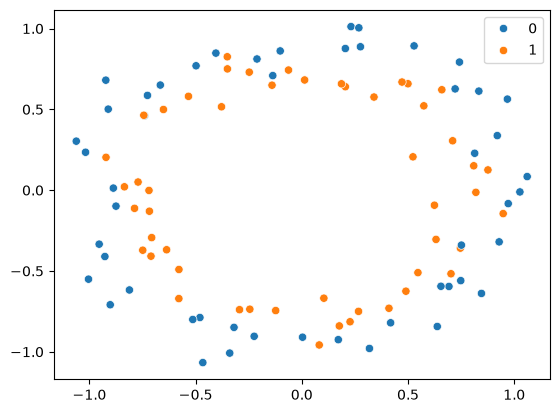

In [3]:
sns.scatterplot(x=X[:,0],y=X[:,1],hue=y)
plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=2)

In [5]:
model = Sequential()

model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

C:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [7]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=3500, verbose=0)

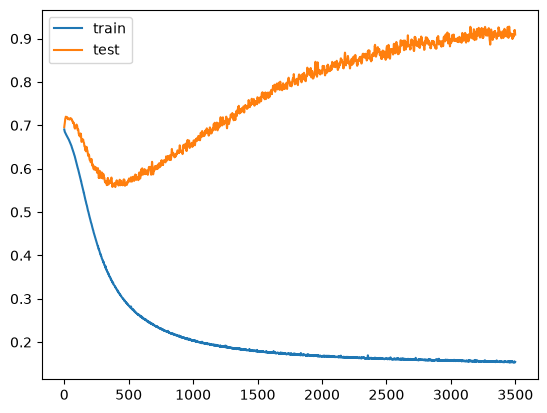

In [8]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

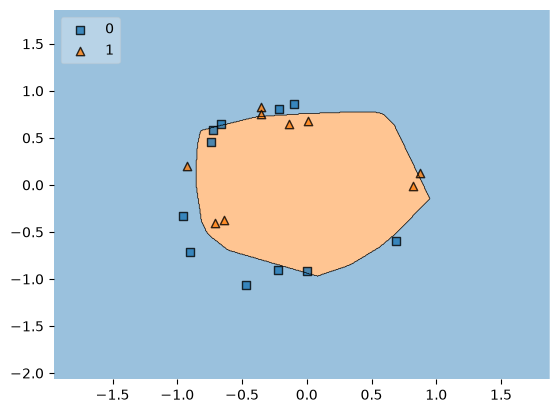

In [9]:
class KerasClassifierWrapper:
    def __init__(self, model):
        self.model = model

    def predict(self, X):
        return (self.model.predict(X, verbose=0) > 0.5).astype(int).ravel()

clf = KerasClassifierWrapper(model)

plot_decision_regions(X_test, y_test.ravel(), clf = clf, legend=2)
plt.show()

# Early Stopping

In [54]:
model1 = Sequential()

model1.add(Dense(256, input_dim=2, activation='relu'))
model1.add(Dense(1, activation='sigmoid'))

In [55]:
model1.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [56]:
callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.00001,
    patience=110,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False
)

In [57]:
history1 = model1.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=3500, callbacks=callback)

Epoch 1/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 181ms/step - accuracy: 0.4375 - loss: 0.6956 - val_accuracy: 0.6000 - val_loss: 0.6897
Epoch 2/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.5250 - loss: 0.6934 - val_accuracy: 0.4500 - val_loss: 0.6939
Epoch 3/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5250 - loss: 0.6920 - val_accuracy: 0.3000 - val_loss: 0.6971
Epoch 4/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5500 - loss: 0.6902 - val_accuracy: 0.3500 - val_loss: 0.6990
Epoch 5/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5375 - loss: 0.6890 - val_accuracy: 0.3000 - val_loss: 0.7013
Epoch 6/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5375 - loss: 0.6879 - val_accuracy: 0.3500 - val_loss: 0.7032
Epoch 7/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5375 - loss: 0.6869 - val_accuracy: 0.3500 - val_loss: 0.7058
Epoch 8/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5500 - loss: 0.6861 - val_accuracy: 0.3500 - 

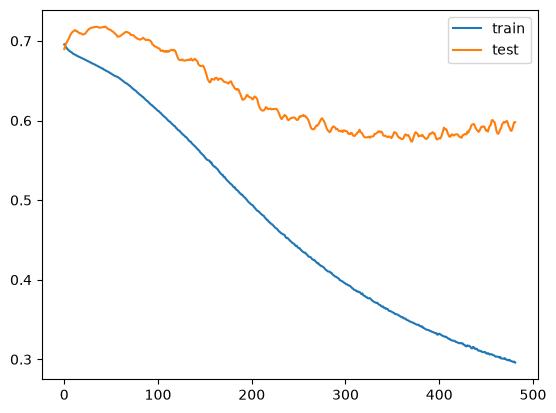

In [58]:
plt.plot(history1.history['loss'], label='train')
plt.plot(history1.history['val_loss'], label='test')
plt.legend()
plt.show()

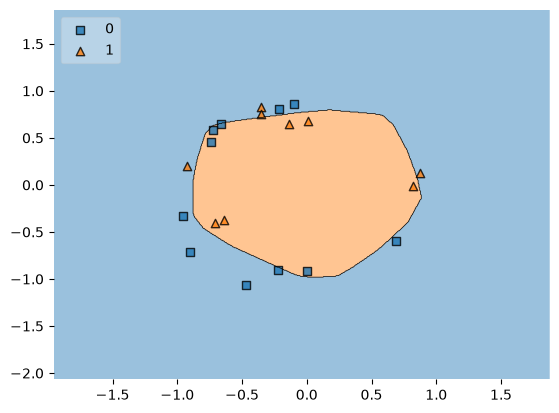

In [59]:
class KerasClassifierWrapper:
    def __init__(self, model1):
        self.model = model1

    def predict(self, X):
        return (self.model.predict(X, verbose=0) > 0.5).astype(int).ravel()

clf = KerasClassifierWrapper(model1)

plot_decision_regions(X_test, y_test.ravel(), clf = clf, legend=2)
plt.show()